In [2]:
# Cell 1: Imports
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE' # This fixes the OpenMP kernel crash!

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2lab, lab2rgb

# Import Microsoft's DirectML plugin for Windows AMD hardware
import torch_directml

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("🚀 NVIDIA GPU Detected! Using CUDA.")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🍏 Apple Silicon Detected! Using MPS.")
else:
    try:
        import torch_directml
        if torch_directml.is_available():
            device = torch_directml.device()
            print("🎮 AMD/Windows GPU Detected! Using DirectML.")
        else:
            raise ImportError
    except ImportError:
        device = torch.device("cpu")
        print("🐌 No recognized GPU found. Falling back to CPU. (This will be slow!)")

🎮 AMD/Windows GPU Detected! Using DirectML.


In [ ]:
# Cell 2: Combined Folder Streaming Loader (With Limit Switch)
import os
from PIL import Image
import random
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import torch
from skimage.color import rgb2lab

class CocoStreamingDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform
        print(f"Dataset initialized with {len(self.data_list)} images.")

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        # 1. Get the filename and the specific folder it lives in
        filename, folder_path = self.data_list[idx]
        img_path = os.path.join(folder_path, filename)
        
        # 2. Load and process
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
            
        img_np = np.array(img)
        img_lab = rgb2lab(img_np).astype(np.float32) 
        img_lab = torch.tensor(img_lab).permute(2, 0, 1)
        
        L = img_lab[[0], ...] / 50.0 - 1.0 
        ab = img_lab[[1, 2], ...] / 110.0 
        
        return L, ab

# --- DATASET COMBINATION LOGIC ---
folder_val = './coco_data_128/val2017'
folder_unlabeled = './coco_data_128/unlabeled2017'

all_image_info = []
for folder in [folder_val, folder_unlabeled]:
    if os.path.exists(folder):
        files = [f for f in os.listdir(folder) if f.endswith(('.jpg', '.png'))]
        for f in files:
            all_image_info.append((f, folder))

random.shuffle(all_image_info)

# ==========================================
# 🛑 THE EDITABLE LIMIT SWITCH
# Set to a number (e.g., 5000) for a fast test.
# Set to None to use ALL 128k images.
MAX_IMAGES = None 
# ==========================================

if MAX_IMAGES is not None:
    all_image_info = all_image_info[:MAX_IMAGES]
    print(f"⚠️ TEST MODE ACTIVE: Limiting dataset to {MAX_IMAGES} images.")

# Split the data (95% Train, 5% Val)
train_size = int(0.95 * len(all_image_info))
train_data = all_image_info[:train_size]
test_data = all_image_info[train_size:]

print(f"✅ Combined Dataset successful!")
print(f"Total images being used: {len(all_image_info):,}")
print(f"Training on: {len(train_data):,} images")
print(f"Validating on: {len(test_data):,} images")

# --- INITIALIZE LOADERS ---
transform = transforms.Compose([transforms.Resize((128, 128))])

train_dataset = CocoStreamingDataset(train_data, transform=transform)
test_dataset = CocoStreamingDataset(test_data, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

✅ Combined Dataset successful!
Total images being used: 128,403
Training on: 121,982 images
Validating on: 6,421 images
Dataset initialized with 121982 images.
Dataset initialized with 6421 images.


In [ ]:
# Cell 3: U-Net Model Definition
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.down1 = DoubleConv(1, 64)       # Input is 1 channel (L)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)
        
        # Decoder
        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.up_conv1 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.up_conv2 = DoubleConv(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.up_conv3 = DoubleConv(128, 64)
        
        # Output is 2 channels (ab)
        self.out_conv = nn.Conv2d(64, 2, 1)

    def forward(self, x):
        # Downsampling
        x1 = self.down1(x)
        p1 = self.pool1(x1)
        x2 = self.down2(p1)
        p2 = self.pool2(x2)
        x3 = self.down3(p2)
        p3 = self.pool3(x3)
        
        # Bottleneck
        bn = self.bottleneck(p3)
        
        # Upsampling with skip connections
        u1 = self.up1(bn)
        u1 = torch.cat([u1, x3], dim=1)
        u1 = self.up_conv1(u1)
        
        u2 = self.up2(u1)
        u2 = torch.cat([u2, x2], dim=1)
        u2 = self.up_conv2(u2)
        
        u3 = self.up3(u2)
        u3 = torch.cat([u3, x1], dim=1)
        u3 = self.up_conv3(u3)
        
        out = self.out_conv(u3)
        return torch.tanh(out) # Tanh because AB channels are normalized between -1 and 1

import os

# 1. Initialize the model and move it to your GPU
model = UNet().to(device)
save_path = 'best_colorizer.pth'

# 2. Establish the global "score to beat" 
all_time_best_loss = float('inf')

# 3. Check if we have a saved checkpoint
if os.path.exists(save_path):
    print("🧠 Found previous training data! Loading...")
    # Map the save to the correct device (DirectML/GPU)
    checkpoint = torch.load(save_path, map_location=device)
    
    # Check if this is the new upgraded "Dictionary" format
    if isinstance(checkpoint, dict) and 'model_state' in checkpoint:
        model.load_state_dict(checkpoint['model_state'])
        all_time_best_loss = checkpoint['best_loss']
        print(f"📈 Loaded previous best score to beat: {all_time_best_loss:.4f}")
    else:
        # Fallback for your very first file that didn't have the score attached
        model.load_state_dict(checkpoint)
        print("⚠️ Loaded old save format. Score to beat reset to Infinity.")
else:
    print("🌱 No previous save found. Starting fresh with an empty brain.")

🧠 Found previous training data! Loading...
📈 Loaded previous best score to beat: 0.0772


C:\Users\axela\AppData\Local\Temp\ipykernel_18056\2634935369.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path, map_location=device)


### Runs
## run 1:
# Cifar dataset optimizer = optim.Adam(model.parameters(), lr=5e-5), patience = 12 earlyStop 24 Train Loss: 0.0565 | Validation Loss: 0.0743

In [ ]:
# Cell 4: Training with Early Stopping
import copy # NEW: Needed to copy weights to RAM safely

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=5e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

num_epochs = 100 

patience = 12  # How many epochs to wait for an improvement before giving up
epochs_without_improvement = 0

# Track the best score for this specific training run
current_run_best_loss = float('inf')
best_run_weights = None

print("Starting Training with Early Stopping...")
for epoch in range(num_epochs):
    # --- 1. TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    
    for L, ab in train_loader:
        L, ab = L.to(device), ab.to(device)
        
        optimizer.zero_grad()
        outputs = model(L)
        loss = criterion(outputs, ab)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
    avg_train_loss = running_train_loss / len(train_loader)
    
    # --- 2. VALIDATION PHASE (The Test) ---
    model.eval() # Tell the model to stop learning for a second
    running_val_loss = 0.0
    
    with torch.no_grad():
        for L_val, ab_val in test_loader:
            L_val, ab_val = L_val.to(device), ab_val.to(device)
            
            val_outputs = model(L_val)
            val_loss = criterion(val_outputs, ab_val)
            running_val_loss += val_loss.item()
            
    avg_val_loss = running_val_loss / len(test_loader)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f}")

    scheduler.step(avg_val_loss)
    
    # --- 3. EARLY STOPPING LOGIC (RAM ONLY) ---
    if avg_val_loss < current_run_best_loss:
        # The AI did better than ever before this session!
        current_run_best_loss = avg_val_loss
        epochs_without_improvement = 0
        
        # Save a deep copy of the brain to RAM, NOT to the hard drive!
        best_run_weights = copy.deepcopy(model.state_dict())
        print(f"  -> ✨ Run improved! Best loss this session: {current_run_best_loss:.4f}")
    else:
        # The AI didn't improve. 
        epochs_without_improvement += 1
        print(f"  -> ⚠️ No improvement for {epochs_without_improvement} epoch(s).")
        
    # If it hasn't improved in "patience" epochs, kill the loop.
    if epochs_without_improvement >= patience:
        print(f"\n🛑 Early stopping triggered! The AI stopped improving after epoch {epoch + 1 - patience}.")
        break

print("\nTraining Complete!")

# --- 4. THE FINAL COMPARISON (Disk Saving) ---
if current_run_best_loss < all_time_best_loss:
    print(f"🏆 NEW HIGH SCORE! This run ({current_run_best_loss:.4f}) beat the old record ({all_time_best_loss:.4f})!")
    
    # Overwrite the file on disk
    checkpoint = {
        'model_state': best_run_weights,
        'best_loss': current_run_best_loss
    }
    torch.save(checkpoint, 'best_colorizer.pth')
    print("💾 Saved new best brain to disk.")
    
    # Load it into the model for the visualization cell below
    model.load_state_dict(best_run_weights)
else:
    print(f"📉 No new record. This run ({current_run_best_loss:.4f}) did not beat the all-time best ({all_time_best_loss:.4f}).")
    print("💾 Keeping the old save file.")
    
    # Reload the old all-time best for the visualization cell below
    checkpoint = torch.load('best_colorizer.pth', map_location=device)
    model.load_state_dict(checkpoint['model_state'])

print("Loaded the absolute best model weights for visualization.")

c:\Users\axela\anaconda3\envs\torch_new\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting Training with Early Stopping...


c:\Users\axela\anaconda3\envs\torch_new\lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


Epoch [1/100] | Train Loss: 0.0775 | Validation Loss: 0.0770
  -> ✨ Run improved! Best loss this session: 0.0770
Epoch [2/100] | Train Loss: 0.0759 | Validation Loss: 0.0760
  -> ✨ Run improved! Best loss this session: 0.0760
Epoch [3/100] | Train Loss: 0.0749 | Validation Loss: 0.0751
  -> ✨ Run improved! Best loss this session: 0.0751
Epoch [4/100] | Train Loss: 0.0741 | Validation Loss: 0.0750
  -> ✨ Run improved! Best loss this session: 0.0750
Epoch [5/100] | Train Loss: 0.0734 | Validation Loss: 0.0742
  -> ✨ Run improved! Best loss this session: 0.0742
Epoch [6/100] | Train Loss: 0.0728 | Validation Loss: 0.0735
  -> ✨ Run improved! Best loss this session: 0.0735
Epoch [7/100] | Train Loss: 0.0723 | Validation Loss: 0.0735
  -> ✨ Run improved! Best loss this session: 0.0735
Epoch [8/100] | Train Loss: 0.0717 | Validation Loss: 0.0734
  -> ✨ Run improved! Best loss this session: 0.0734
Epoch [9/100] | Train Loss: 0.0711 | Validation Loss: 0.0733
  -> ✨ Run improved! Best loss this

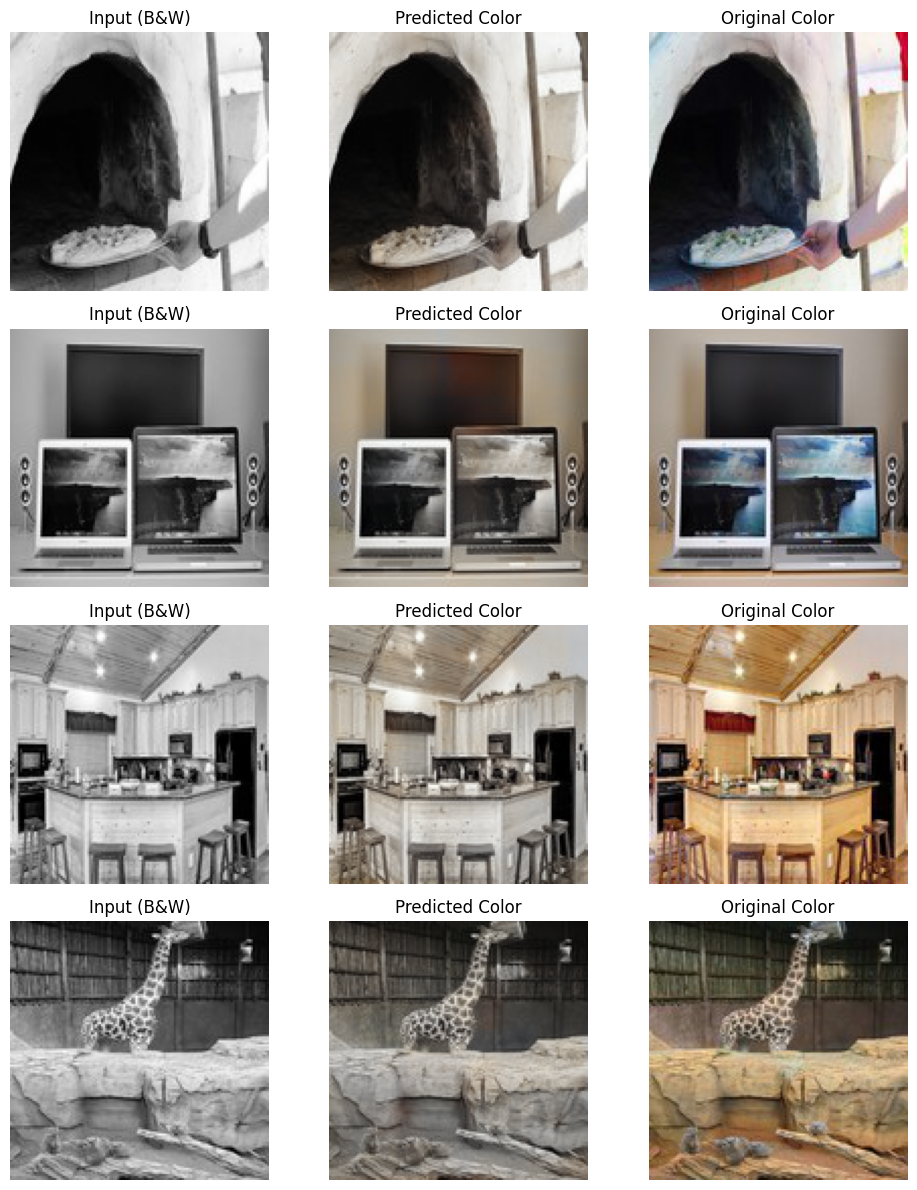

In [ ]:
# Cell 5: Visualization (Corrected for DirectML)
def to_rgb(L, ab):
    """Helper function to convert tensors back to RGB images for plotting."""
    L = L.to("cpu")
    ab = ab.to("cpu")
    
    L = (L + 1.0) * 50.0 # Denormalize L
    ab = ab * 110.0      # Denormalize ab
    
    # Concatenate L and ab
    lab = torch.cat([L, ab], dim=0).detach().numpy()
    lab = lab.transpose((1, 2, 0)) # (H, W, 3)
    
    # Convert to RGB and clip to valid ranges
    rgb = lab2rgb(lab)
    return np.clip(rgb, 0, 1)

model.eval()
# Grab a batch of test data
data_iter = iter(test_loader)
L_test, ab_test = next(data_iter)

# Move input to GPU for prediction
L_test_gpu = L_test.to(device)
with torch.no_grad():
    ab_pred = model(L_test_gpu)

# Plot 4 examples
fig, axes = plt.subplots(4, 3, figsize=(10, 12))
for i in range(4):
    # 1. Grayscale Input (Using L channel)
    L_img = L_test[i].numpy().transpose(1, 2, 0)
    axes[i, 0].imshow(L_img.squeeze(), cmap='gray')
    axes[i, 0].set_title("Input (B&W)")
    axes[i, 0].axis('off')
    
    # 2. Predicted Color (Pass the GPU prediction - the function now handles the move to CPU)
    pred_rgb = to_rgb(L_test[i], ab_pred[i])
    axes[i, 1].imshow(pred_rgb)
    axes[i, 1].set_title("Predicted Color")
    axes[i, 1].axis('off')
    
    # 3. Ground Truth (Original Color)
    true_rgb = to_rgb(L_test[i], ab_test[i])
    axes[i, 2].imshow(true_rgb)
    axes[i, 2].set_title("Original Color")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()